# LST Analysis with MODIS/Landset

Install & Authenticate

In [ ]:
!pip install earthengine-api geemap

In [ ]:
import ee
import geemap

# Authenticate
ee.Authenticate()
ee.Initialize()

# Urban vs Rural

In [ ]:
# Urban point (Bhopal)
urban = ee.Geometry.Point([77.4126, 23.2599])

# Rural point (away from city)
rural = ee.Geometry.Point([77.0, 23.5])

# Buffer regions (10 km)
urban_roi = urban.buffer(10000)
rural_roi = rural.buffer(10000)

Load Landsat 8 Collection

In [ ]:
def load_landsat(roi):
    collection = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
                  .filterBounds(roi)
                  .filterDate('2022-01-01', '2022-12-31')
                  .filter(ee.Filter.lt('CLOUD_COVER', 20)))
    return collection

Cloud Masking Function

In [ ]:
def mask_landsat(image):
    qa = image.select('QA_PIXEL')

    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    shadow = qa.bitwiseAnd(1 << 4).eq(0)

    return image.updateMask(cloud.And(shadow))

NDVI Calculation

In [ ]:
def add_ndvi(image):
    ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    return image.addBands(ndvi)

LST CALCULATION

# Formula Used

$$
LST = \frac{BT}{1 + \left(\frac{\lambda \, BT}{\rho}\right)\ln(\varepsilon)}
$$

Implementation

In [ ]:
def calculate_lst(image):
    # Step 1: Convert Thermal Band (Band 10) to Radiance
    radiance = image.select('ST_B10').multiply(0.00341802).add(149.0)

    # Step 2: Brightness Temperature
    bt = radiance.rename('BT')

    # Step 3: NDVI
    ndvi = image.select('NDVI')

    # Step 4: Emissivity Calculation
    ndvi_min = 0.2
    ndvi_max = 0.5

    pv = ((ndvi.subtract(ndvi_min))
          .divide(ndvi_max - ndvi_min)
          .pow(2))

    emissivity = pv.multiply(0.004).add(0.986).rename('EM')

    # Step 5: LST Calculation
    lst = bt.expression(
        '(BT / (1 + (0.00115 * BT / 1.4388) * log(EM))) - 273.15',
        {
            'BT': bt,
            'EM': emissivity
        }).rename('LST')

    return image.addBands(lst)

Pipelines

In [ ]:
def process_collection(roi):
    collection = load_landsat(roi)

    processed = (collection
                 .map(mask_landsat)
                 .map(add_ndvi)
                 .map(calculate_lst))

    return processed

Generate Mean LST

In [ ]:
urban_collection = process_collection(urban_roi)
rural_collection = process_collection(rural_roi)

urban_lst = urban_collection.select('LST').mean()
rural_lst = rural_collection.select('LST').mean()

Visualization

In [ ]:
Map = geemap.Map()

vis_params = {
    'min': 20,
    'max': 45,
    'palette': ['blue', 'green', 'yellow', 'red']
}

Map.centerObject(urban_roi, 9)

Map.addLayer(urban_lst, vis_params, 'Urban LST')
Map.addLayer(rural_lst, vis_params, 'Rural LST')

Map

Map(center=[23.25991025887323, 77.41260030966079], controls=(WidgetControl(options=['position', 'transparent_b…

Urban vs Rural Comparison

In [ ]:
def get_mean_temp(image, region):
    return image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=30
    ).get('LST')

urban_temp = get_mean_temp(urban_lst, urban_roi)
rural_temp = get_mean_temp(rural_lst, rural_roi)

print("Urban Mean LST:", urban_temp.getInfo())
print("Rural Mean LST:", rural_temp.getInfo())

Urban Mean LST: 36.911678419386526
Rural Mean LST: 40.90470195462546


In [ ]:
Cal = rural_temp.getInfo() - urban_temp.getInfo()
print("Difference in Mean LST:", Cal)

Difference in Mean LST: 3.993023535238933


# Time Series Plot

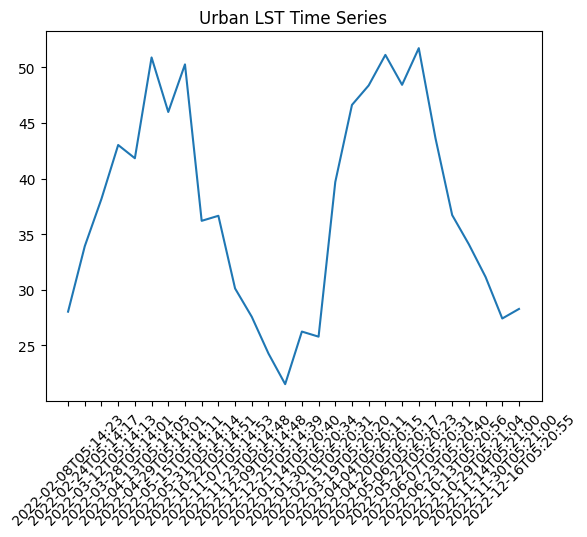

In [ ]:
import matplotlib.pyplot as plt

def get_time_series(collection, region):
    def extract(image):
        stat = image.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=region,
            scale=30
        )
        return ee.Feature(None, {
            'date': image.date().format(),
            'LST': stat.get('LST')
        })

    return collection.map(extract)

urban_ts = get_time_series(urban_collection, urban_roi)

# Convert to list
features = urban_ts.getInfo()['features']

dates = [f['properties']['date'] for f in features]
temps = [f['properties']['LST'] for f in features]

plt.figure()
plt.plot(dates, temps)
plt.xticks(rotation=45)
plt.title("Urban LST Time Series")
plt.savefig('Urban LST Time Series.png')
plt.show()

Exporting LST Map

In [ ]:
task = ee.batch.Export.image.toDrive(
    image=urban_lst,
    description='Urban_LST_Map',
    scale=30,
    region=urban_roi.getInfo()['coordinates'],
    fileFormat='GeoTIFF'
)

task.start()

NDVI vs LST Scatter Plot

In [ ]:
# Combine NDVI and LST bands
combined = urban_collection.select(['NDVI', 'LST']).mean()

Sample Pixels from Region

In [ ]:
# Sample pixels (IMPORTANT: limit to avoid overload)
samples = combined.sample(
    region=urban_roi,
    scale=30,
    numPixels=5000,
    geometries=False
)

Convert to Pandas DataFrame

In [ ]:
import pandas as pd

data = samples.getInfo()['features']

ndvi_vals = [f['properties']['NDVI'] for f in data]
lst_vals = [f['properties']['LST'] for f in data]

df = pd.DataFrame({
    'NDVI': ndvi_vals,
    'LST': lst_vals
})

Plot Scatter

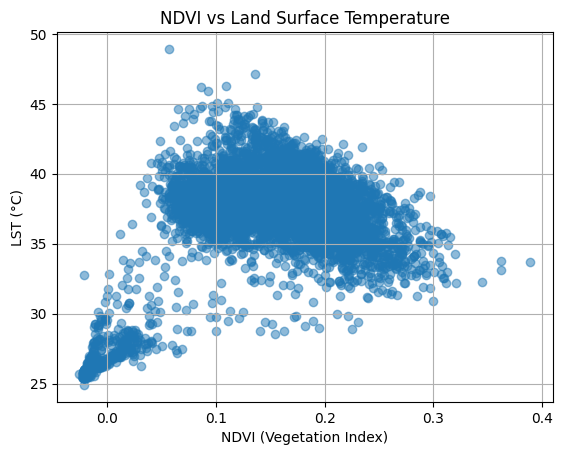

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['NDVI'], df['LST'], alpha=0.5)

plt.xlabel("NDVI (Vegetation Index)")
plt.ylabel("LST (°C)")
plt.title("NDVI vs Land Surface Temperature")

plt.savefig('NDVI vs Land Surface Temperature.png') #download the graph for documentaion use later

plt.grid()
plt.show()

Co-relation

In [ ]:
correlation = df.corr()
print(correlation)

          NDVI       LST
NDVI  1.000000  0.384212
LST   0.384212  1.000000


Regression

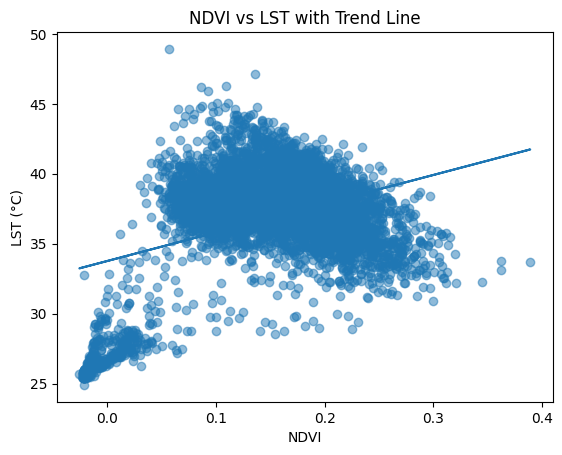

In [ ]:
import numpy as np

z = np.polyfit(df['NDVI'], df['LST'], 1)
p = np.poly1d(z)

plt.figure()
plt.scatter(df['NDVI'], df['LST'], alpha=0.5)
plt.plot(df['NDVI'], p(df['NDVI']))

plt.xlabel("NDVI")
plt.ylabel("LST (°C)")
plt.title("NDVI vs LST with Trend Line")
plt.savefig('NDVI vs LST with Trend Line.png')
plt.show()

# Filterign & Season isolation

Seasonal Noice

In [ ]:
# Better representation (reduces seasonal noise)
combined = urban_collection.select(['NDVI', 'LST']).median()

Sample Pixels

In [ ]:
samples = combined.sample(
    region=urban_roi,
    scale=30,
    numPixels=5000,
    geometries=False
)

Convert to DataFrame

In [ ]:
import pandas as pd

data = samples.getInfo()['features']

ndvi_vals = [f['properties']['NDVI'] for f in data]
lst_vals = [f['properties']['LST'] for f in data]

df = pd.DataFrame({
    'NDVI': ndvi_vals,
    'LST': lst_vals
})

Applying filter

In [ ]:
# Remove low NDVI (water/bare soil noise)
df = df[df['NDVI'] > 0.1]

## Recreating plots and Correlation

### Scatter Plot

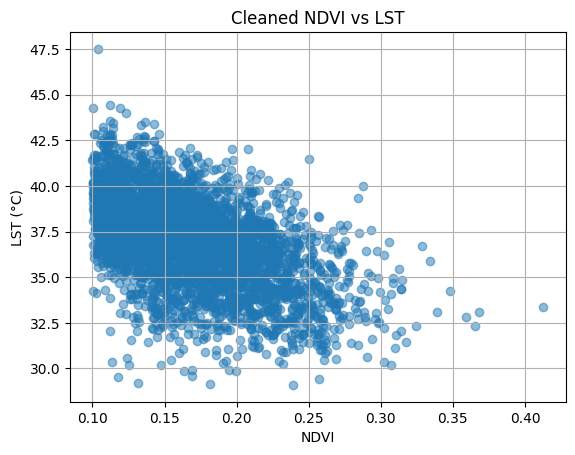

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['NDVI'], df['LST'], alpha=0.5)

plt.xlabel("NDVI")
plt.ylabel("LST (°C)")
plt.title("Cleaned NDVI vs LST")
plt.grid()
plt.savefig('Cleaned NDVI vs LST.png')
plt.show()

###Trend line

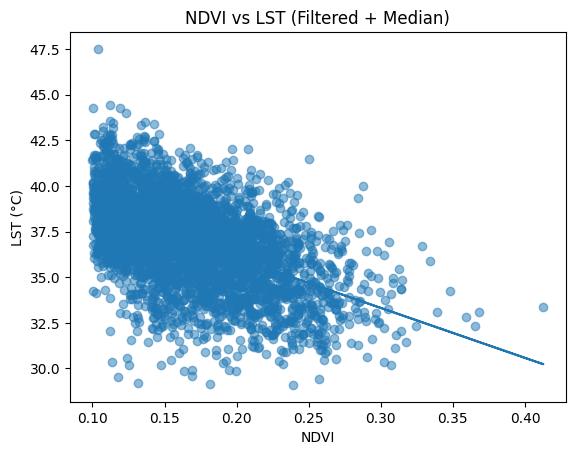

In [ ]:
import numpy as np

z = np.polyfit(df['NDVI'], df['LST'], 1)
p = np.poly1d(z)

plt.figure()
plt.scatter(df['NDVI'], df['LST'], alpha=0.5)
plt.plot(df['NDVI'], p(df['NDVI']))

plt.xlabel("NDVI")
plt.ylabel("LST (°C)")
plt.title("NDVI vs LST (Filtered + Median)")
plt.savefig('NDVI vs LST (Filtered + Median.png')
plt.show()

###Correlation

In [ ]:
correlation = df.corr()
print(correlation)

          NDVI       LST
NDVI  1.000000 -0.508625
LST  -0.508625  1.000000


# MODIS vs LANDSAT LST COMPARISON

Loading MODIS LST Dataset

In [ ]:
def load_modis(roi):
    collection = (ee.ImageCollection('MODIS/061/MOD11A2')
                  .filterBounds(roi)
                  .filterDate('2022-01-01', '2022-12-31'))
    return collection

MODIS LST to Celsius

In [ ]:
def process_modis(collection):
    def convert(image):
        lst = image.select('LST_Day_1km') \
                   .multiply(0.02) \
                   .subtract(273.15) \
                   .rename('LST')
        return lst.copyProperties(image, ['system:time_start'])

    return collection.map(convert)

Mean MODIS LST

In [ ]:
modis_collection = process_modis(load_modis(urban_roi))
modis_lst = modis_collection.mean()

Comparison with Landsat

In [ ]:
# Landsat mean (already computed earlier)
landsat_lst = urban_lst

Getting Mean Temperature Values

In [ ]:
def get_mean(image, region, scale):
    return image.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=scale
    ).get('LST')

modis_temp = get_mean(modis_lst, urban_roi, 1000)
landsat_temp = get_mean(landsat_lst, urban_roi, 30)

print("MODIS Mean LST:", modis_temp.getInfo())
print("Landsat Mean LST:", landsat_temp.getInfo())

MODIS Mean LST: 32.145251030215235
Landsat Mean LST: 36.911678419386526


In [ ]:
print("Difference in Mean LST:", modis_temp.getInfo() - landsat_temp.getInfo())

Difference in Mean LST: -4.766427389171291


Comparison Plot

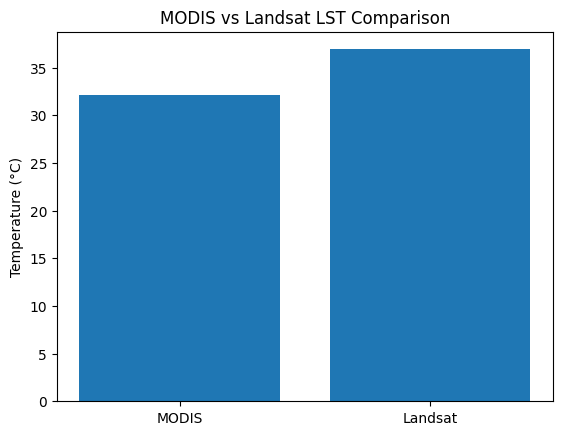

In [ ]:
import matplotlib.pyplot as plt

labels = ['MODIS', 'Landsat']
values = [modis_temp.getInfo(), landsat_temp.getInfo()]

plt.figure()
plt.bar(labels, values)

plt.ylabel("Temperature (°C)")
plt.title("MODIS vs Landsat LST Comparison")
plt.savefig('MODIS vs Landsat LST Comparison.png')
plt.show()

### Exporting GeoTIFFs Data

Urban LST

In [ ]:
task_urban = ee.batch.Export.image.toDrive(
    image=urban_lst,
    description='urban_lst',
    folder='LST_Project',
    fileNamePrefix='urban_lst',
    region=urban_roi.getInfo()['coordinates'],
    scale=30,
    fileFormat='GeoTIFF'
)
task_urban.start()

Rural LST

In [ ]:
task_rural = ee.batch.Export.image.toDrive(
    image=rural_lst,
    description='rural_lst',
    folder='LST_Project',
    fileNamePrefix='rural_lst',
    region=rural_roi.getInfo()['coordinates'],
    scale=30,
    fileFormat='GeoTIFF'
)
task_rural.start()

MODIS LST

In [ ]:
task_modis = ee.batch.Export.image.toDrive(
    image=modis_lst,
    description='modis_lst',
    folder='LST_Project',
    fileNamePrefix='modis_lst',
    region=urban_roi.getInfo()['coordinates'],
    scale=1000,
    fileFormat='GeoTIFF'
)
task_modis.start()

Creating a summary stats file

In [ ]:
import pandas as pd

# Get values
urban_val = urban_temp.getInfo()
rural_val = rural_temp.getInfo()
modis_val = modis_temp.getInfo()
landsat_val = landsat_temp.getInfo()

uhi = urban_val - rural_val
modis_diff = modis_val - landsat_val

# Create dataframe
df_stats = pd.DataFrame({
    'Metric': [
        'Urban Mean LST',
        'Rural Mean LST',
        'UHI Difference',
        'NDVI-LST Correlation',
        'MODIS Mean LST',
        'Landsat Mean LST',
        'MODIS-Landsat Difference'
    ],
    'Value': [
        urban_val,
        rural_val,
        uhi,
        -0.508625,  # your computed value
        modis_val,
        landsat_val,
        modis_diff
    ]
})

# Save CSV
df_stats.to_csv('summary_stats.csv', index=False)

df_stats

,Metric,Value
0,Urban Mean LST,36.911678
1,Rural Mean LST,40.904702
2,UHI Difference,-3.993024
3,NDVI-LST Correlation,-0.508625
4,MODIS Mean LST,32.145251
5,Landsat Mean LST,36.911678
6,MODIS-Landsat Difference,-4.766427


map in png

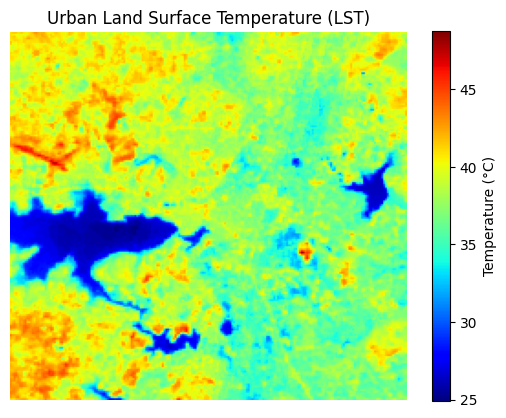

In [93]:
import geemap
import matplotlib.pyplot as plt

# Convert to numpy array
lst_array = geemap.ee_to_numpy(urban_lst, region=urban_roi, scale=100)


plt.figure()
plt.imshow(lst_array, cmap='jet')
plt.colorbar(label='Temperature (°C)')
plt.title('Urban Land Surface Temperature (LST)')

plt.axis('off')

plt.savefig('lst_map.png', bbox_inches='tight', dpi=300)
